# **Seminar 1 — Linear Regression for Wi-Fi Throughput Prediction**
Name: Pau Martínez Carrión (u232318) NIA:285580

1. **Part I: Data preparation & analysis**
    - Create a module that processes the data. The main operations your module must do are:
        - Loading the dataset from the .txt file and storing the data in a structured manner.
        - Displaying statistics about each feature (mean, standard deviation).
        - Plotting relevant figures to visualize how data is distributed.
        - Processing the data (e.g., cleaning, normalization, categorical, etc.) and prepare it to be used by an ML model.
        - Splitting the data into different partitions to be used for training (e.g., 80%) and testing (e.g., 20%).
        
2. **Part II: Model implementation**
    - Create a module that trains and evaluates a linear regression model. The main operations your module must do are:
        - Fitting the data into an ML model (in this case, a multi-variable linear regression),i.e., estimating the coefficients of the model.
        - Evaluating the performance of the model using a given error function.
        - Plotting the results visually (e.g., training loss, test accuracy).

#### **Core libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# **Part I**

## **1. Load the dataset**

In [3]:
df = pd.read_csv("dataset_Seminar1.txt", sep=r"\s+")

df.columns = [
    'num_STAs',           # Number of STAs (1-40)
    'load',               # Load (0.5-82 Mbps)
    'size_x',             # Size(x) (1-40 m)
    'size_y',             # Size(y) (1-40 m)
    'area',               # Area (xy)
    'contention_window',  # Contention window (slots)
    'channel_width',      # Channel width (MHz)
    'packet_size',        # Packet size (bits)
    'max_RSSI',           # Max RSSI (dBm)
    'avg_RSSI',           # Avg RSSI (dBm)
    'min_RSSI',           # Min RSSI (dBm)
    'prob_failure',       # Avg. Probability of failure (0-1)
    'throughput',         # Throughput (bps) - TARGET LABEL
    'avg_delay',          # Average delay (seconds)
    'total_airtime',      # Total airtime
    'prop_airtime'        # Proportional airtime
]

# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (99999, 16)

Dataset columns:
['num_STAs', 'load', 'size_x', 'size_y', 'area', 'contention_window', 'channel_width', 'packet_size', 'max_RSSI', 'avg_RSSI', 'min_RSSI', 'prob_failure', 'throughput', 'avg_delay', 'total_airtime', 'prop_airtime']

First few rows:
   num_STAs        load  size_x  size_y    area  contention_window  \
0      35.0  52500000.0    20.0    33.0   660.0               31.0   
1      16.0  12000000.0    34.0    14.0   476.0              255.0   
2      37.0  18500000.0    35.0     7.0   245.0               31.0   
3      18.0   4500000.0    36.0    35.0  1260.0              127.0   
4       3.0    750000.0    27.0    11.0   297.0              511.0   

   channel_width  packet_size   max_RSSI   avg_RSSI   min_RSSI  prob_failure  \
0           40.0      10000.0 -47.815800 -63.298410 -72.847989      0.485311   
1           40.0       4000.0 -46.138494 -60.076333 -70.044800      0.099413   
2           80.0      10000.0 -42.708813 -60.141393 -72.029643 

## **2. Dataset Statistics**

In [67]:
# Calculate statistics for each feature
statistics = pd.DataFrame({
    'Feature': df.columns,
    'Mean': df.mean().values,
    'Std Dev': df.std().values,
    'Min': df.min().values,
    'Max': df.max().values
})

print("=" * 100)
print("FEATURE STATISTICS")
print("=" * 100)
print(statistics.to_string(index=False))

FEATURE STATISTICS
          Feature          Mean      Std Dev           Min           Max
         num_STAs  2.144598e+01 1.155427e+01      2.000000  4.100000e+01
             load  2.140253e+07 1.852011e+07 500000.000000  8.200000e+07
           size_x  2.056293e+01 1.154526e+01      1.000000  4.000000e+01
           size_y  2.047945e+01 1.154053e+01      1.000000  4.000000e+01
             area  4.212660e+02 3.603435e+02      1.000000  1.600000e+03
contention_window  2.270456e+02 3.233521e+02      3.000000  1.023000e+03
    channel_width  7.510595e+01 5.370455e+01     20.000000  1.600000e+02
      packet_size  7.997620e+03 2.825518e+03   4000.000000  1.200000e+04
         max_RSSI -4.591120e+01 5.400284e+00    -81.405165 -4.086359e+01
         avg_RSSI -5.757737e+01 6.108553e+00    -81.405165 -4.086596e+01
         min_RSSI -6.646774e+01 8.057523e+00    -84.333834 -4.086596e+01
     prob_failure  2.266742e-01 2.248479e-01      0.000209  7.654220e-01
       throughput  9.716034e+06 

## **3. Data Visualization**

In this section, we plot a few relevant figures to understand how the data is distributed. According to the seminar slides we focus on throughput as the target variable.

#### 3.1 Histogram of throughput

- This tells you whether throughput values are mostly low, medium, or high

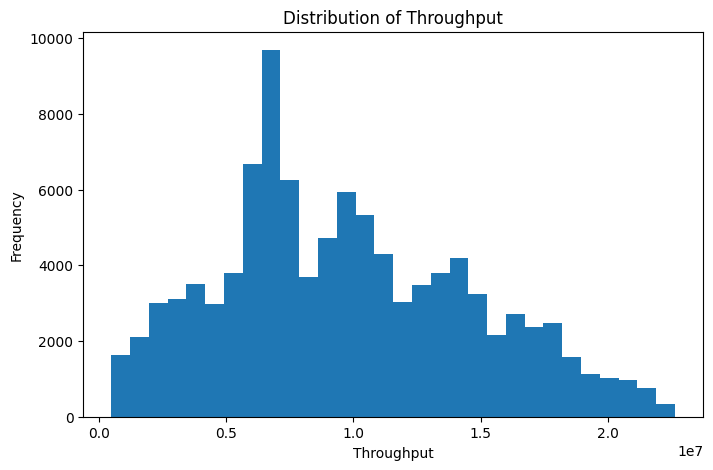

In [68]:
plt.figure(figsize=(8,5))
plt.hist(df["throughput"], bins=30)
plt.title("Distribution of Throughput")
plt.xlabel("Throughput")
plt.ylabel("Frequency")
plt.show()

#### 3.2 Histograms of other important features 

- Instead of plotting all 11 features at once, choose 3 or 4 easy ones.

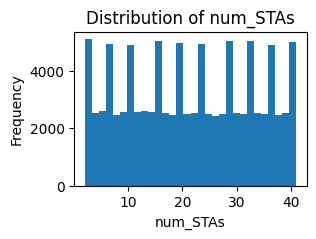

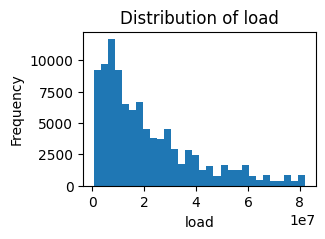

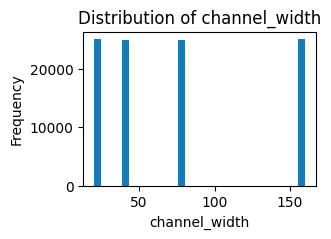

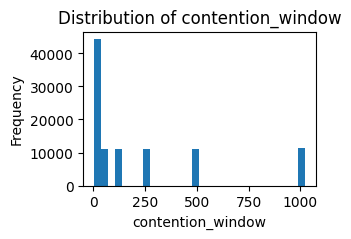

In [69]:
features_to_plot = ["num_STAs", "load", "channel_width", "contention_window"]

for col in features_to_plot:
    plt.figure(figsize=(3,2))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

#### 3.3 Scatter plots: feature vs throughput

What this tells you is:
- whether there may be a relationship with throughput
- whether the relation looks linear or not
- whether the data is very spread out

This is very useful since we are going to use linear regression, so it makes sense to visually inspect whether throughput seems related to the features.

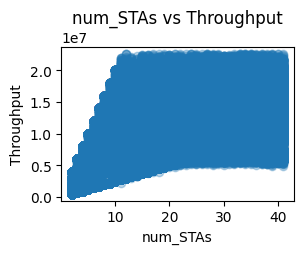

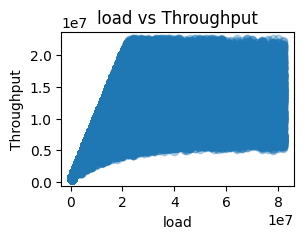

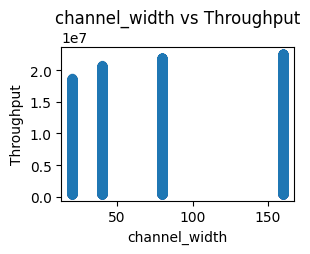

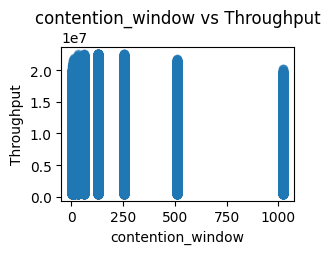

In [70]:
features_to_compare = ["num_STAs", "load", "channel_width", "contention_window"]

for col in features_to_compare:
    plt.figure(figsize=(3,2))
    plt.scatter(df[col], df["throughput"], alpha=0.3)
    plt.title(f"{col} vs Throughput")
    plt.xlabel(col)
    plt.ylabel("Throughput")
    plt.show()

## **4. Processing Data before training**

The dataset is processed before training the model. 
- First, missing values are checked to ensure the data is clean. 
- Then, the 11 Wi-Fi configuration and signal-related columns are selected as input features, while throughput is selected as the target label.
- Finally, the input features are normalized using standardization so that all variables are on a similar scale before applying linear regression.

In [71]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Select input features and target
feature_cols = [
    'num_STAs',        
    'load',              
    'size_x',          
    'size_y',       
    'area',               
    'contention_window', 
    'channel_width',      
    'packet_size',        
    'max_RSSI',           
    'avg_RSSI',           
    'min_RSSI',
]

X = df[feature_cols]
y = df["throughput"]

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert normalized data back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("\nFirst rows of normalized features:")
print(X_scaled.head())

Missing values in each column:
num_STAs             0
load                 0
size_x               0
size_y               0
area                 0
contention_window    0
channel_width        0
packet_size          0
max_RSSI             0
avg_RSSI             0
min_RSSI             0
prob_failure         0
throughput           0
avg_delay            0
total_airtime        0
prop_airtime         0
dtype: int64

Shape of X: (99999, 11)
Shape of y: (99999,)

First rows of normalized features:
   num_STAs      load    size_x    size_y      area  contention_window  \
0  1.173080  1.679127 -0.048758  1.084924  0.662521          -0.606294   
1 -0.471342 -0.507696  1.163866 -0.561455  0.151895           0.086452   
2  1.346177 -0.156724  1.250482 -1.168015 -0.489163          -0.606294   
3 -0.298245 -0.912663  1.337098  1.258227  2.327607          -0.309403   
4 -1.596472 -1.115147  0.557554 -0.821409 -0.344856           0.878163   

   channel_width  packet_size  max_RSSI  avg_RSSI  min_RSSI  

## **5. Split the data**

The dataset was divided into two partitions: 80% for training and 20% for testing. The model will be trained on one subset of the data and evaluated on a different unseen subset, which will help measure how well it generalizes.

In [72]:
# Split the processed data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Display the size of each partition
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (79999, 11)
X_test shape: (20000, 11)
y_train shape: (79999,)
y_test shape: (20000,)


# **Part II**

## **1. Linear regression model fitting**

In this section, a **multi-variable linear regression model** is trained using the training data. The purpose of this model is to learn the relationship between the Wi-Fi input features and the target variable, which is the **throughput**.

Linear regression is based on the following equation:

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n
$$

where:

- $\hat{y}$ represents the **predicted throughput**
- $x_1, x_2, \dots, x_n$ represent the **input features**
- $\theta_0$ is the **intercept**
- $\theta_1, \theta_2, \dots, \theta_n$ are the **coefficients of the model**

Therefore, fitting the model means estimating these coefficients so that the model can predict throughput from the available Wi-Fi features.

In [73]:
# Create the linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Display intercept
print("Intercept:", model.intercept_)

# Display coefficients with feature names
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print("\nModel coefficients:")
print(coef_df)

Intercept: 9712121.730831014

Model coefficients:
              Feature   Coefficient
0            num_STAs  8.290549e+05
1                load  1.779226e+06
2              size_x -1.537536e+06
3              size_y -1.555866e+06
4                area  1.205419e+06
5   contention_window -3.478201e+05
6       channel_width  4.161003e+05
7         packet_size  2.430013e+06
8            max_RSSI  5.544414e+05
9            avg_RSSI  2.008684e+05
10           min_RSSI -1.508545e+06


## **2. Model evaluation**

After training the linear regression model, its performance is evaluated on the test set. This step measures how close the predicted throughput values are to the real throughput values.

To evaluate the model, the following regression metrics are used:

- **Mean Squared Error (MSE)**: measures the average squared difference between the real and predicted values. Note: MSE is on the scale of throughput squared (bits per second)², so large values are expected.
- **Mean Absolute Error (MAE)**: measures the average absolute difference between the real and predicted values. Like MSE, it is on the scale of throughput (bits per second).
- **R² score**: indicates how well the model explains the variability of the target variable. Ranges from 0 to 1, where higher is better.

Ideally, we want a high R² score (e.g., > 0.8). MSE and MAE values depend on the data scale, so they are best used for comparing different models trained on the same dataset rather than judging absolute model quality.

In [74]:
# Predict throughput on the test set
y_pred = model.predict(X_test)

# Compute evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("Model evaluation results:")
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R² score:", r2)

Model evaluation results:
Mean Squared Error (MSE): 9767407166843.783
Mean Absolute Error (MAE): 2509809.1956067355
R² score: 0.5983010570679876


## **3. Visual representation of the results**

Two plots are used:

- **Actual vs Predicted Throughput**: compares the real throughput values with the values predicted by the model
- **Residual Plot**: shows the prediction errors, that is, the difference between the real and predicted values

These figures help interpret whether the model predictions are close to the real values and whether the errors appear randomly distributed.

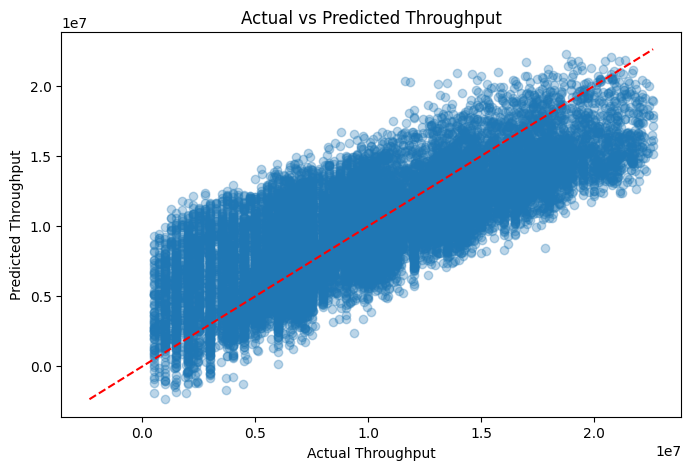

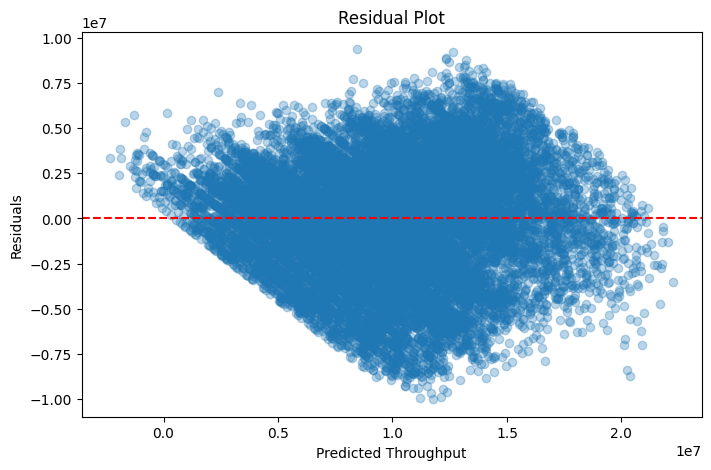

In [75]:
# Plot 1: Actual vs Predicted with diagonal reference line
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.3)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")

plt.xlabel("Actual Throughput")
plt.ylabel("Predicted Throughput")
plt.title("Actual vs Predicted Throughput")
plt.show()

# Plot 2: Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Throughput")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()